In [88]:
from pathlib import Path
import pandas as pd
from dotenv import load_dotenv
import os
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL

In [89]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [90]:
load_dotenv()

True

In [91]:
db_host = os.getenv("DB_HOST")
db_name = os.getenv("DB_NAME")
db_user = os.getenv("DB_USER")
db_password = os.getenv("DB_PASSWORD")
db_port = os.getenv("DB_PORT")

In [92]:
db_url = URL.create(
    drivername="postgresql+psycopg2",
    username=db_user,
    password=db_password,
    host=db_host,
    port=int(db_port) if db_port else 5432,
    database=db_name,
 )
engine = create_engine(db_url)

In [93]:
c_df = pd.read_sql(text("SELECT * FROM dim_company"), con=engine)
s_df = pd.read_sql(text("SELECT * FROM dim_sector"), con=engine)
y_df = pd.read_sql(text("SELECT * FROM dim_year"), con=engine)
bs_df = pd.read_sql(text("SELECT * FROM fact_balance_sheet"), con=engine)
cf_df = pd.read_sql(text("SELECT * FROM fact_cash_flow"), con=engine)
pl_df = pd.read_sql(text("SELECT * FROM fact_profit_loss"), con=engine)

In [94]:
df = pl_df.merge(bs_df, on=["symbol", "year_id"], how="inner").merge(cf_df, on=["symbol", "year_id"], how="inner")

In [95]:
df = df.merge(c_df, on="symbol", how="inner")
df = df.merge(s_df, on="sector_id", how="inner")
df = df.merge(y_df, on="year_id", how="inner")

In [96]:
df = df.drop(columns=[
    "shares_outstanding",
    "book_value_per_share"
])

In [97]:
df = df.drop(columns=[
    "face_value",
    "book_value"
])

In [98]:
df = df.fillna({
    "interest_coverage": 0,
    "opm_pct": 0,
    "operating_profit": 0,
    "dividend_payout_pct": 0,
    "eps": 0,
    "cash_conversion_ratio": 0
})

In [99]:
df = df.fillna(0)

In [100]:
df.columns

Index(['symbol', 'year_id', 'sales', 'expenses', 'operating_profit', 'opm_pct',
       'other_income', 'interest', 'depreciation', 'profit_before_tax',
       'tax_pct', 'net_profit', 'eps', 'dividend_payout_pct',
       'net_profit_margin_pct', 'expense_ratio_pct', 'interest_coverage',
       'asset_turnover', 'return_on_assets', 'equity_capital', 'reserves',
       'borrowings', 'other_liabilities', 'total_liabilities', 'fixed_assets',
       'cwip', 'investments', 'other_asset', 'total_assets', 'debt_to_equity',
       'equity_ratio', 'operating_activity', 'investing_activity',
       'financing_activity', 'net_cash_flow', 'free_cash_flow',
       'cash_conversion_ratio', 'company_name', 'sector_id', 'sub_sector',
       'company_logo', 'website', 'nse_url', 'bse_url', 'about_company',
       'sector_name', 'sector_code', 'description', 'year_label',
       'fiscal_year', 'quarter', 'is_ttm', 'is_half_year', 'sort_order'],
      dtype='str')

PROFITABILITY

In [101]:
df['profitability'] = (df['net_profit_margin_pct'] + df['return_on_assets']) / 2
df['profitability'].head()

0    -2.881549
1     1.449114
2    14.818094
3    13.856654
4    12.379350
Name: profitability, dtype: float64

REVENUE GROWTH

In [102]:
df = df.sort_values(['symbol', 'year_id'])
        
df['revenue_growth'] = df.groupby('symbol')['sales'].pct_change()

df['revenue_growth'].head()

4         NaN
5    0.376891
6    0.005712
7    0.141983
8    0.110559
Name: revenue_growth, dtype: float64

LEVERAGE

In [103]:
df['de_ratio'] = df['debt_to_equity']
df['de_ratio']

4        0.000000
5        0.000000
6        0.000000
7        0.000000
8        0.000000
          ...    
1051    14.861724
1052    15.100497
1053    15.320317
1054    14.758883
1055    12.823705
Name: de_ratio, Length: 1068, dtype: float64

CASH FLOW QUALITY

In [104]:
df['cash_flow_quality'] = df['free_cash_flow'] / df['net_profit'].replace(0, np.nan)
df['cash_flow_quality'].head()

4    0.289655
5    0.000000
6   -8.292576
7    2.854902
8    1.657040
Name: cash_flow_quality, dtype: float64

DIVIDEND TRACK RECORD

In [105]:
df['dividend_score'] = df['dividend_payout_pct']
df['dividend_score'].head()

4    25.0
5    25.0
6    29.0
7    29.0
8    31.0
Name: dividend_score, dtype: float64

GROWTH TREND (profit growth)

In [106]:
df['profit_growth'] = df.groupby('symbol')['net_profit'].pct_change()
df['profit_growth'].head()

4         NaN
5    0.365517
6    0.156566
7    0.113537
8    0.086275
Name: profit_growth, dtype: float64

In [107]:
df = df.replace([np.inf, -np.inf], np.nan)

df[['revenue_growth', 'profit_growth', 'cash_flow_quality']] = \
    df[['revenue_growth', 'profit_growth', 'cash_flow_quality']].fillna(0)

In [108]:
df['dividend_score'] = df['dividend_score'].replace(-999, 0)

df['dividend_score'] = df['dividend_score'].clip(0, 100)

df['profitability'] = df['profitability'].clip(-100, 100)

df['revenue_growth'] = df['revenue_growth'].clip(-1, 1)

df['de_ratio'] = df['de_ratio'].clip(0, 10)

df['cash_flow_quality'] = df['cash_flow_quality'].clip(-5, 5)

df['profit_growth'] = df['profit_growth'].clip(-1, 1)

In [109]:
df[['profitability','revenue_growth','de_ratio','cash_flow_quality','dividend_score','profit_growth']].describe()

,profitability,revenue_growth,de_ratio,cash_flow_quality,dividend_score,profit_growth
count,1068.000000,1068.000000,1068.000000,1068.000000,1068.000000,1068.000000
mean,13.599163,0.126793,1.926472,0.138809,28.454120,0.092209
std,20.189660,0.206431,2.938645,2.157460,23.844756,0.465906
min,-100.000000,-0.656802,0.000000,-5.000000,0.000000,-1.000000
25%,4.857723,0.005238,0.041024,-0.434617,11.000000,-0.071704
50%,9.338070,0.100054,0.521128,0.375307,24.000000,0.090841
75%,15.446961,0.193683,2.085593,1.010359,40.000000,0.300850
max,100.000000,1.000000,10.000000,5.000000,100.000000,1.000000


In [110]:
df['profitability_score'] = df['profitability'].rank(pct=True) * 100
df['revenue_growth_score'] = df['revenue_growth'].rank(pct=True) * 100
df['cashflow_score'] = df['cash_flow_quality'].rank(pct=True) * 100
df['dividend_score_norm'] = df['dividend_score'].rank(pct=True) * 100
df['growth_trend_score'] = df['profit_growth'].rank(pct=True) * 100

In [111]:
df['leverage_score'] = (1 - df['de_ratio'].rank(pct=True)) * 100

In [112]:
df['health_score'] = (
    0.25 * df['profitability_score'] +
    0.20 * df['revenue_growth_score'] +
    0.20 * df['leverage_score'] +
    0.15 * df['cashflow_score'] +
    0.10 * df['dividend_score_norm'] +
    0.10 * df['growth_trend_score']
)

In [113]:
def label_score(score):
    if score >= 85:
        return "EXCELLENT"
    elif score >= 70:
        return "GOOD"
    elif score >= 50:
        return "AVERAGE"
    elif score >= 35:
        return "WEAK"
    else:
        return "POOR"
    
df['health_label'] = df['health_score'].apply(label_score)

In [114]:
df[['company_name','year_id','health_score','health_label']].head()

,company_name,year_id,health_score,health_label
4,Abbott India Ltd,201212,54.382022,AVERAGE
5,Abbott India Ltd,201403,72.497659,GOOD
6,Abbott India Ltd,201503,53.611891,AVERAGE
7,Abbott India Ltd,201603,73.291199,GOOD
8,Abbott India Ltd,201703,68.815543,AVERAGE


In [115]:
output_path = Path("data/EDA_ML/financial_data.csv")
if not output_path.parent.exists():
    output_path = Path("..") / "data" / "EDA_ML" / "financial_data.csv"

output_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(output_path, index=False)

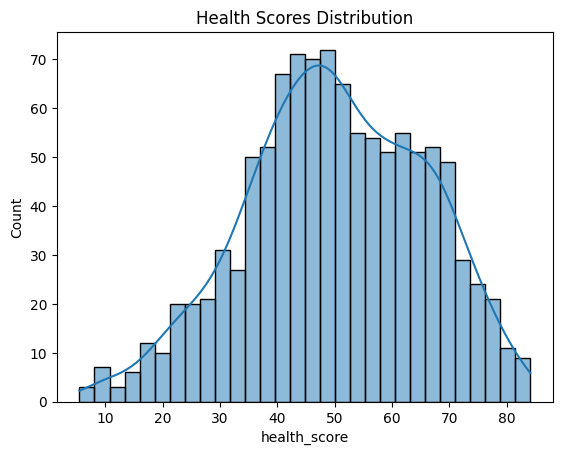

In [116]:
sns.histplot(df['health_score'], bins=30, kde=True)
plt.title("Health Scores Distribution")
plt.show()